### Astrostatistic Lecture 20

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import stats
import corner
import h5py
plt.rcParams['figure.facecolor'] = 'black' #custom plot stuff
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'         
plt.rcParams['axes.labelcolor'] = 'white'  
plt.rcParams['text.color'] = 'white'  
plt.rcParams['xtick.color'] = 'white'           
plt.rcParams['ytick.color'] = 'white'

data = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r')

keys = list(data.keys())
print(keys)    
features = []
for key in keys:
    if key != 'snr' and key != 'det':
        features.append(key) 

['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']


100%|██████████| 11/11 [01:15<00:00,  6.87s/it]


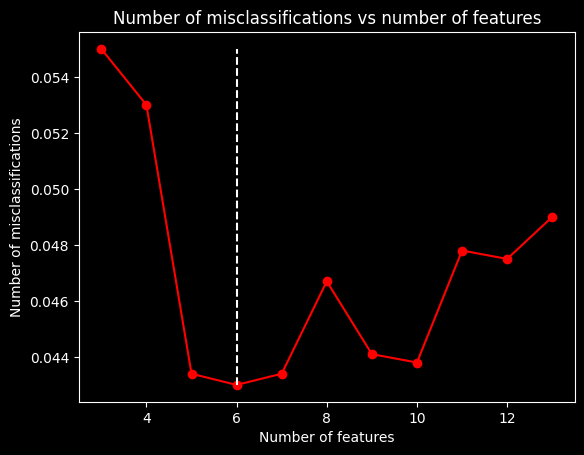

In [ ]:
#first let's see what features we need to use, starting from a smaller data sample
lenght = 10000 
det = data['det'][:lenght]      #this will be our target
used_features = ['mtot', 'q', 'z', 'psi', 'iota', 'ra', 'dec', 'chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z']
scores = []
leng = []

for used in tqdm(range(3, len(used_features)+1)):
    Feat = used_features[:used]
    real_data = np.column_stack([data[f][:lenght] for f in Feat])

    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

    cv_score = cross_val_score(rf, real_data, det, cv=5, scoring='accuracy')
    
    error = 1 - np.mean(cv_score)
    importance = rf.feature_importances_
    scores.append(error)
    leng.append(len(Feat))
plt.plot(leng, scores, marker='o', color='red')
plt.vlines(np.argmin(scores)+3, np.min(scores), np.max(scores), color='white', ls='dashed', lw=1.5, label='best-fit theta')
plt.title('Number of misclassifications vs number of features')
plt.xlabel('Number of features')
plt.ylabel('Number of misclassifications')
plt.show()

In [ ]:
#just keep the first 4 features, they are enough, now we can cross validate the depth of the forest
keeped_features = used_features[:4]
print(keeped_features)
used_data = np.column_stack([data[f][:lenght] for f in keeped_features])
X_train, X_test, y_train, y_test = train_test_split(used_data, det, test_size=0.2, random_state=42)

for d in tqdm(range(2,16)):
    rf = RandomForestClassifier(10, max_depth=d, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    

['mtot', 'q', 'z', 'psi']
